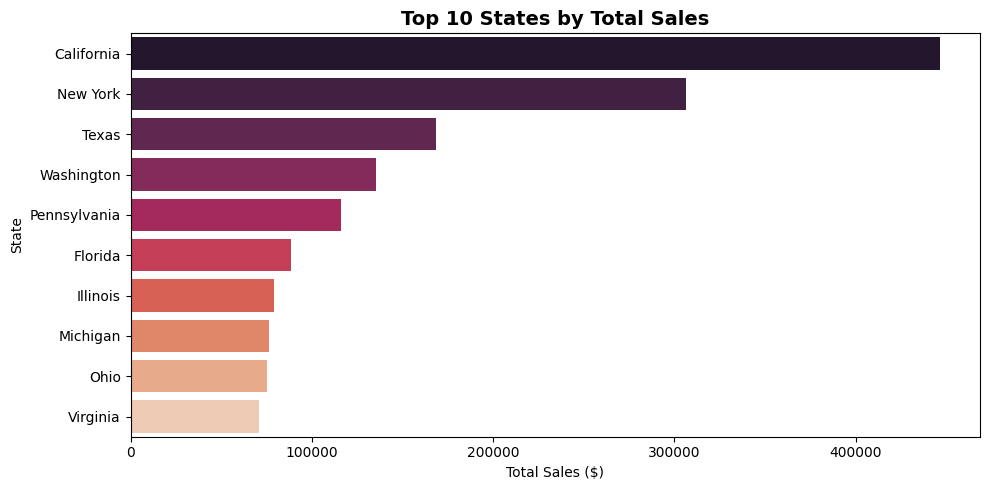

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../Task_1_Data_Cleaning/cleaned_superstore.csv')

state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=state_sales, x='Sales', y='State', hue='State', palette='rocket')
plt.title('Top 10 States by Total Sales', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

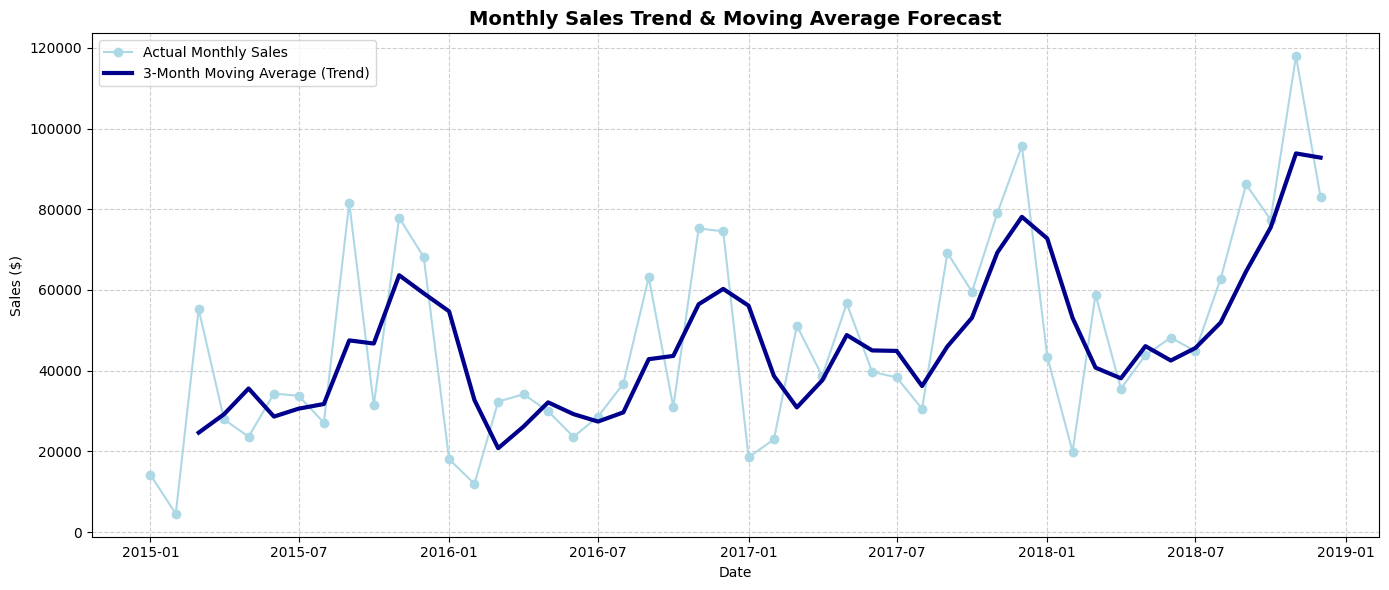

In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Month_Year'] = df['Order_Date'].dt.to_period('M')

monthly_sales = df.groupby('Month_Year')['Sales'].sum().reset_index()
monthly_sales['Month_Year'] = monthly_sales['Month_Year'].dt.to_timestamp()

monthly_sales['3-Month_MA'] = monthly_sales['Sales'].rolling(window=3).mean()

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['Month_Year'], monthly_sales['Sales'], label='Actual Monthly Sales', color='lightblue', marker='o')
plt.plot(monthly_sales['Month_Year'], monthly_sales['3-Month_MA'], label='3-Month Moving Average (Trend)', color='darkblue', linewidth=3)

plt.title('Monthly Sales Trend & Moving Average Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()